# Implementing YOLO11 for Real-time Weapon Detection
___

Developed by Muhammad Arkana Yudhistira

**Table of Contents**

1. [Background](#0)
2. [Introduction to Object Detection](#1)
3. [Working with YOLO11](#2)
4. [Weapon Detection with YOLO11 Model](#3)
5. [Real World Applications](#4)

In [ ]:
from ultralytics import YOLO
from PIL import Image
import pandas as pd
import numpy as np
import os
import cv2

# Background <a id="0" ></a>

Tingkat kejahatan yang semakin meningkat menyebabkan keselamatan masyarakat semakin mengkhawatirkan. Oleh karena itu, dibutuhkan solusi inovatif untuk meningkatkan keamanan dan menjamin ketenangan masyarakat. Course ini dirancang agar peserta dapat mempelajari cara menerapkan teknik machine learning tingkat lanjut, **Object Detection**, dan menggunakannya untuk menyelesaikan masalah pada dunia nyata. Dengan mengeksplorasi YOLO11 (You Only Look Once), sebuah algoritma object detection yang terkenal dengan kecepatan dan akurasinya yang luar biasa, Anda akan mengeksplorasi dan menerapkan sistem yang mampu mendeteksi kejahatan dalam berbagai situasi.

# Introduction to Object Detection <a id="1" ></a>

Seiring kemajuan perkembangan teknologi **computer vision**, kemampuan komputer untuk memahami dunia visual telah meningkat. Salah satu aplikasi paling fundamental dan serbaguna dalam computer vision adalah **image classification**, dimana sebuah sistem dapat belajar untuk mengidentifikasi sebuah gambar untuk diklasifikasikan ke dalam satu atau lebih kategori. 

Namun, kini computer vision sudah berkembang lebih jauh lagi. Selain mengenali apa objek yang ada dalam sebuah gambar, tetapi juga dapat menentukan lokasi dan ukuran objek tersebut. Task tersebut dapat dilakukan oleh algoritma **object detection**. Object detection melakukan identifikasi lokasi suatu objek dengan melakukan prediksi **bounding box**, kotak yang membungkus objek terdeteksi dalam sebuah gambar. 

![Object Detection](https://deeplobe.ai/wp-content/uploads/2023/06/Object-detection-Real-world-applications-and-benefits.png)

## Object Detection vs Image Classification 

Object detection dan image classification merupakan dua task computer vision yang sering kali dikira serupa, namun sebenarnya memiliki perbedaan yang signifikan. Berikut merupakan perbedaan dari kedua task tersebut:

|              | Image Classification                         | Object Detection                                          |
|--------------|----------------------------------------------|-----------------------------------------------------------|
| Tujuan       | Klasifikasi seluruh bagian gambar            | Identifikasi lokasi dan klasifikasi objek di dalam gambar |
| Output       | Label kategori                               | Label kategori dan koordinat bounding box                 |
| Target       | 1 kategori                                   | Banyak kategori                                           |
| Kompleksitas | Lebih sederhana, waktu komputasi lebih cepat | Lebih kompleks, waktu komputasi lebih lambat              |
| Model        | CNN, ResNet, VGG, Inception                  | YOLO, Faster R-CNN, SSD                                   |

## Object Detection with YOLO Algorithm

YOLO (You Only Look Once) adalah algoritma object detection yang populer karena kecepatan dan keakuratannya, sehingga memungkinkan object detection secara real-time. YOLO memiliki metode yang memungkinkan untuk melakukan prediksi objek serta bounding box secara sekaligus. Berbeda dengan algoritma lain yang melakukan prediksi secara berulang untuk mendapatkan lokasi objek yang diinginkan didalam gambar. Berikut merupakan tahap-tahap cara kerja dari algoritma YOLO:
    
![YOLO Algorithm](https://i.ibb.co/xJYTnvT/yolo-algorithm.png)

1. **Input Image to YOLO Model**
    
    Gambar yang ingin diprediksi diberikan pada algoritma YOLO yang terdiri atas arsitektur CNN (Convolutional Neural Network). YOLO akan mempelajari fitur-fitur yang terdapat pada gambar yang diinput.
    
2. **Grid Prediction**

    YOLO membagi gambar menjadi grid cell dengan jumlah S×S. Kemudian, setiap cell grid akan membuat prediksi bounding box. Prediksi yang dilakukan adalah prediksi terhadap objek yang ada pada bagian gambar tiap grid.
    
3. **Remove Predictions with Low Confidence**

    Setiap prediksi yang dihasilkan oleh tiap grid akan memiliki nilai confidence score yang merupakan nilai probability sebuah bounding box berisi jenis objek tertentu. Bounding box dengan confidence score di bawah threshold (default: 0.25) akan dibuang.
    
4. **Non-Max Suppression (NMS)**

    Pada bounding box yang tersisa, terdapat kemungkinan suatu object diprediksi beberapa kali oleh grid yang berbeda, sehingga terjadi tumpang tindih antar bounding box. **NMS** digunakan untuk menghilangkan bounding box yang berlebihan pada satu object yang sama dengan hanya menyimpan kotak dengan confidence score tertinggi (diukur dengan **Intersection over Union** atau **IoU**).
    
5. **Final Output**

    Hasil dari proses tersebut adalah sekumpulan bounding box, di mana masing-masing memiliki label kelas dan confidence score. Bounding box ini adalah prediksi akhir algoritma YOLO untuk objek pada gambar baru.

# Working with YOLO11 <a id="2" ></a>

YOLO11 adalah versi terbaru YOLO dari Ultralytics. Sebagai model termutakhir, YOLO11 mengembangkan versi-versi sebelumnya, memperkenalkan fitur-fitur baru, serta meningkatkan performa dan efisiensi. Berikut dokumentasi YOLO11 dari Ultralytics : https://docs.ultralytics.com/

## Environment Preparation

Algoritma YOLO dapat kita import dari library ultralytics.

In [3]:
from ultralytics import YOLO

## YOLO11 Model Preparation

YOLO11 menyediakan berbagai varian **model pre-trained** dengan ukuran dan kapabilitas yang berbeda-beda, disesuaikan dengan kebutuhan penggunaan yang spesifik, mulai dari aplikasi yang memerlukan kecepatan tinggi dengan pengorbanan sedikit akurasi, hingga aplikasi yang memerlukan akurasi tinggi tanpa memperdulikan beban komputasi yang lebih besar. **Model pre-trained** adalah model yang telah dilatih untuk mempelajari data dengan jumlah yang sangat besar. 

Berikut perbandingan pilihan input model YOLO11 yang tersedia:

| Model      | mAP (50-95) | Speed - CPU (ms) | Speed - GPU (ms) |
|------------|-------------|------------------|------------------|
| yolo11n.pt | 39.5        | 56.1             | 1.5              |
| yolo11s.pt | 47.0        | 90.0             | 2.5              |
| yolo11m.pt | 51.5        | 183.2            | 4.7              |
| yolo11l.pt | 53.4        | 238.6            | 6.2              |
| yolo11x.pt | 54.7        | 462.8            | 11.3             |

📝 **Note**: `.pt` adalah file extension dari **PyTorch**, sebuah library dengan spesialisasi dalam machine learning yang dapat digunakan untuk membuat dan menyimpan suatu model.

Kita akan coba menggunakan model `yolo11m.pt` sebagai input algoritma YOLO dan kemudian kita simpan pada variabel `model_detection`

In [ ]:
model_detection = YOLO("yolo11m.pt")

## Image Object Detection

Kita akan mencoba untuk melakukan object detection pada suatu gambar.

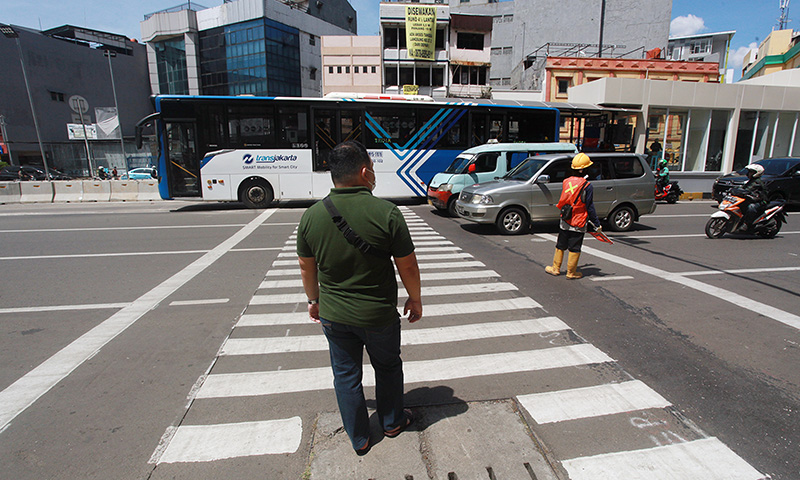

In [ ]:
from PIL import Image

Image.open("data_input/zebra_cross_jkt.jpg")

### Image Prediction

Untuk melakukan object detection, kita dapat menggunakan method `.predict()` dan memberikan input berupa `source` media yang ingin kita prediksi. 

🔻 Berikut pilihan source yang dapat kita input:

- Gambar : `"/path_gambar/gambar.jpg"`
- Video : `"/path_video/video.mp4"`
- Webcam (OpenCV) : `cv2.VideoCapture(0)` 
- URL : `"www.image.com/image.jpg"`
- YouTube : `"www.youtube.com/watch?v=videoyoutube"`


In [ ]:
# Source Gambar dari file directory
result = model_detection.predict(source = ["data_input/zebra_cross_jkt.jpg"]) 


0: 384x640 6 persons, 6 cars, 2 motorcycles, 1 bus, 1 handbag, 83.9ms
Speed: 14.6ms preprocess, 83.9ms inference, 3231.7ms postprocess per image at shape (1, 3, 384, 640)


Output dari prediksi model tersebut adalah sebuah `list` yang berisi `attribute` dari `result` untuk setiap gambar yang diprediksi. Untuk mengakses attribute hasil prediksi untuk gambar pertama, kita dapat menggunakan `result[0].attribute`

### Prediction Result Visualization

Untuk menginterpretasi hasil prediksi pada gambar tersebut, kita akan memvisualisasikan `result` tersebut. Method `.plot()` memvisualisasikan hasil object detection dengan memberikan bounding box, label, dan confidence score ke gambar. Method `.plot()` mengembalikan gambar visualisasi sebagai `array`.

In [11]:
result_array = result[0].plot()

![](https://i.ibb.co/SXP0gkJ/rgb-image.png)

Kita dapat menggunakan fungsi `Image.fromarray()` untuk menampilkan gambar dari sebuah `array`.

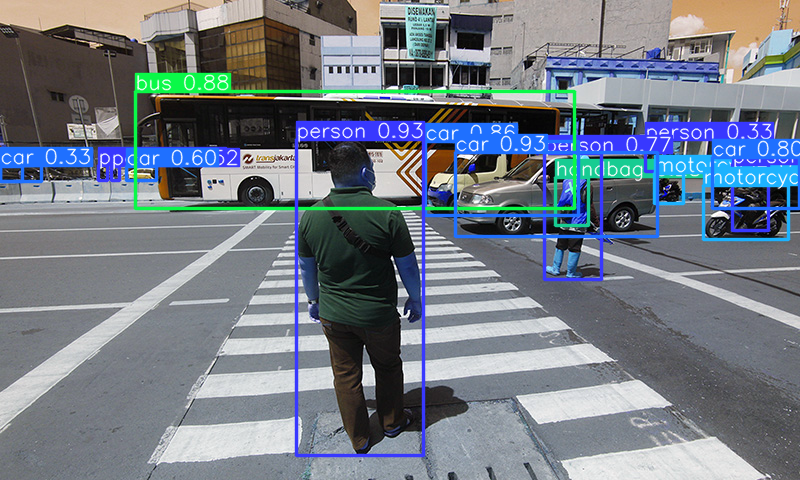

In [13]:
# Menampilkan gambar dari array
Image.fromarray(result_array)

Namun, kita bisa lihat bahwa gambar yang divisualisasikan memiliki warna yang tidak wajar. Hal tersebut terjadi karena format pixel pada array yang dihasilkan oleh method `.plot()` merupakan dalam format warna **BGR**, sementara format yang divisualisasikan **RGB**. 

Maka, kita perlu melakukan convert format **BGR** menjadi **RGB** dengan bantuan **OpenCV** (`cv2`)

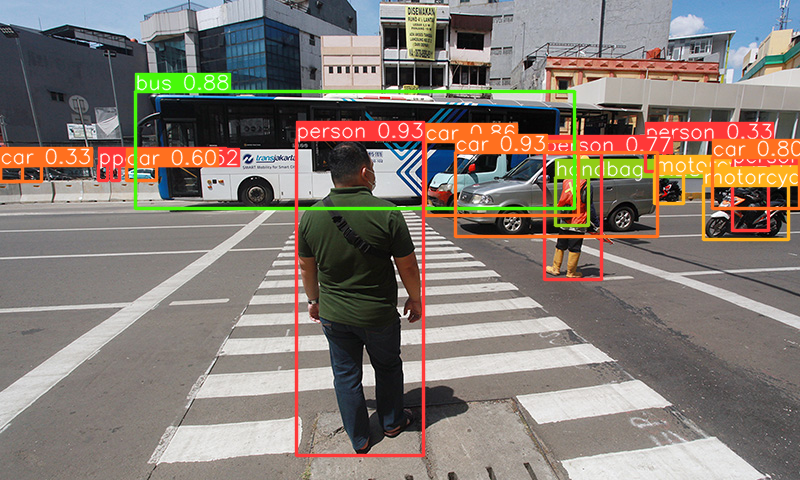

In [14]:
import cv2

result_rgb = cv2.cvtColor(result_array, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
Image.fromarray(result_rgb)  # RGB Image

### Working with Prediction Results

Untuk melakukan analisis lebih lanjut dari hasil prediksi, kita dapat memanfaatkan `attribute` dari `result`. Attribute `.boxes` dapat kita gunakan untuk mendapatkan berbagai karakteristik dari bounding box yang terbentuk, seperti:

- `cls` : Label-label kelas untuk setiap bounding box
- `conf` : Nilai confidence score untuk setiap bounding box
- `xywh` : Koordinat bounding box pada gambar

In [15]:
# Menampilkan attribute dari bounding box hasil prediksi
boxes = result[0].boxes

Kita dapat menggunakan fungsi `len()` untuk menghitung seberapa banyak bounding box yang terprediksi

In [17]:
len(boxes)

16

Untuk menampilkan masing-masing jumlah object yang terdeteksi, kita dapat mendapatkan label-label kelas untuk tiap bounding box menggunakan attribute `.boxes.cls`.

In [18]:
# Menampilkan kelas-kelas terdeteksi dari hasil prediksi
classes = result[0].boxes.cls

In [19]:
classes

tensor([ 0.,  2.,  5.,  2.,  2.,  3.,  0.,  0.,  2.,  0.,  3.,  0.,  2.,  0.,  2., 26.], device='cuda:0')

Kemudian, untuk melakukan perhitungan jumlahnya kita dapat melakukan step-step berikut: 

1. Ubah variabel `classes` menjadi Series pandas dengan fungsi pd.Series
2. Replace angka-angka label menjadi namanya dengan method `.replace()`
3. Hitung jumlah masing-masing label unik menggunakan method `.value_counts()`

In [20]:
import pandas as pd

pd.Series(classes.cpu()).replace(model_detection.names).value_counts()

person        6
car           6
motorcycle    2
bus           1
handbag       1
Name: count, dtype: int64

### Detecting Specific Classes

Parameter `classes=[<nomor_label>]` pada method `predict()` dapat kita gunakan untuk memilih label objek spesifik yang ingin dideteksi dari gambar.

✍ Lakukan deteksi object untuk orang dan mobil pada gambar `zebra_cross_jkt_jpg`!

In [ ]:
result_peoplecar = model_detection.predict(source = "data_input/zebra_cross_jkt.jpg",
                                           classes = [0, 2]) # People dan Car

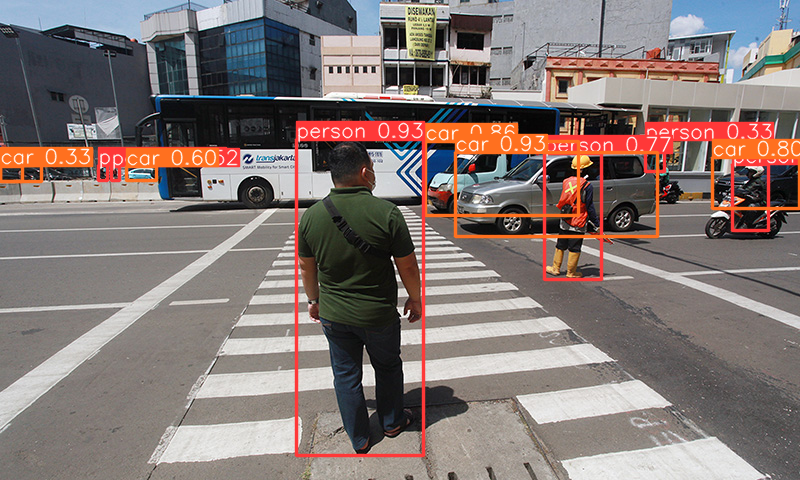

In [23]:
# Menampilkan gambar dari hasil prediksi 
Image.fromarray(cv2.cvtColor(result_peoplecar[0].plot(), cv2.COLOR_BGR2RGB)) 

## Video Object Detection

Video pada dasarnya adalah rangkaian gambar, yang disebut **frame**, diputar secara berurutan untuk menciptakan pergerakan. Ketika kita melakukan prediksi pada sebuah video, sebenarnya kita melakukan prediksi pada beberapa gambar berupa frame.

Jika kita ingin melakukan deteksi objek pada sebuah video, terdapat beberapa parameter dari method `.predict()` yang perlu digunakan:

- `source` : Menentukan sumber data yang akan dilakukan object detection
- `stream` : Melakukan prediksi ketika mengolah `result` secara bersamaan
- `save` : Menyimpan output video dengan objek terdeteksi yang sudah diberikan bounding box
- `classes` : Memilih label objek spesifik yang ingin dideteksi dari video

In [ ]:
result_video = model_detection.predict(source = "data_input/office.mp4",
                                       stream = True,
                                       save = True,
                                       classes = [0]) # People

Variabel `result_video` menyimpan hasil deteksi video yang telah diinput dalam mentuk `Object` yang dapat diproses pada tahap selanjutnya menggunakan **looping**.

📝 **Note** : `Object` disini berbeda dengan **object** dari **object detection**. `Object` pada python merupakan sebuah struktur data yang dapat menyimpan kumpulan data (`attribute`) dan fungsi (`method`).

In [ ]:
# dimunculkan di set ke frame tertentu
frame_list = []

for frame in result_video:
    frame_list.append(frame)

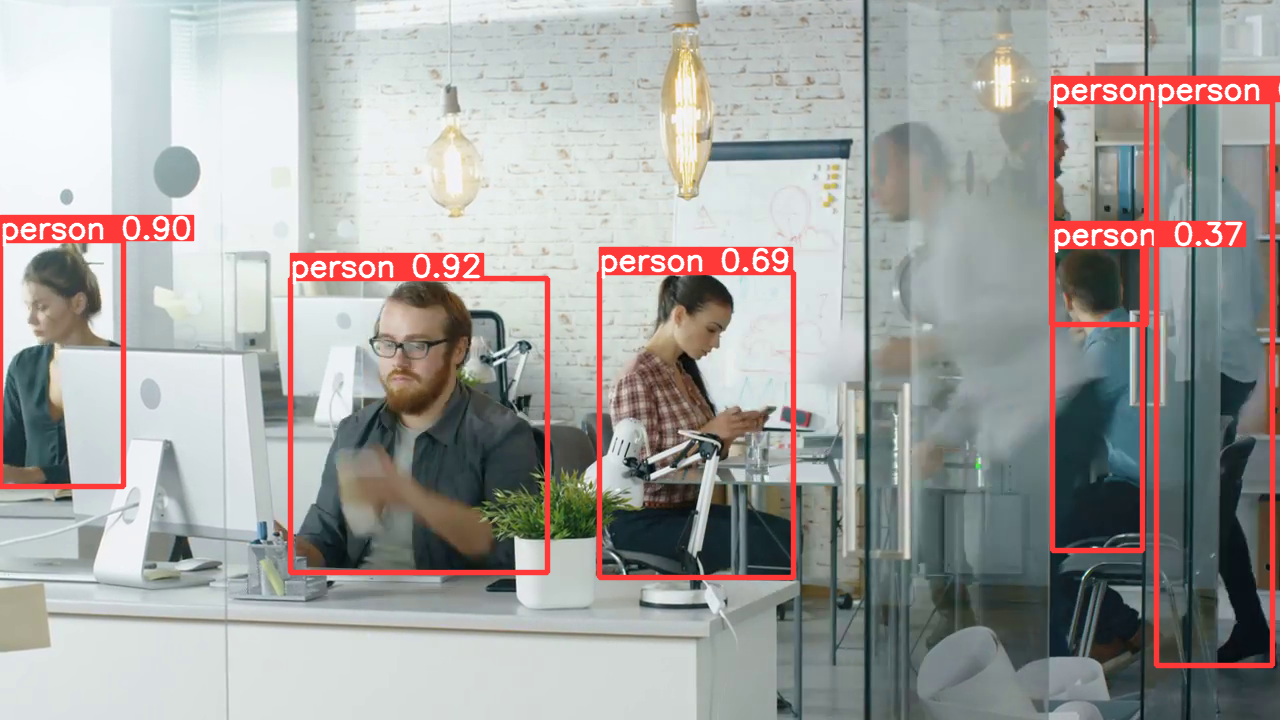

In [ ]:
# Menampilkan gambar hasil prediksi dari frame ke 200 video 
Image.fromarray(cv2.cvtColor(frame_list[200].plot(), cv2.COLOR_BGR2RGB))

# Study Case: Weapon Detection with YOLO11 Model <a id="3" ></a>

Aplikasi object detection pada deteksi senjata dalam video atau gambar merupakan studi kasus yang sangat penting dan relevan, khususnya dalam konteks peningkatan keamanan dan pencegahan tindak kejahatan. Kita akan mengimplementasikan YOLO11 untuk melakukan deteksi senjata.

## Dataset Preparation

YOLO11 membutuhkan kumpulan gambar yang telah dilabeli dengan bounding box untuk melakukan pelatihan model object detection. Kita akan memanfaatkan sebuah tools bernama **Roboflow** untuk membantu kita mempersiapkan dataset. Roboflow adalah platform yang menyederhanakan proses pembuatan dataset dan model computer vision.

🌐 Website Roboflow : https://roboflow.com/

### Option 1: Image Collection using Roboflow Universe

Roboflow Universe menyediakan kumpulan dataset open source untuk computer vision. Kita akan memanfaatkan tools tersebut untuk memperoleh dataset object detection berupa gambar-gambar yang telah dilabeli dengan bounding box. Berikut step-step untuk mempersiapkan dataset melalui Roboflow Universe:

1. Buka website Roboflow Universe melalui https://universe.roboflow.com/
2. Search dataset yang ingin dicari pada search bar
3. Pilih dataset yang paling sesuai dengan objek yang ingin dideteksi (periksa kualitas gambar, jumlah gambar dan kelas-kelas yang tersedia)
4. Pilih `Download Dataset` untuk mengunduh dataset yang diinginkan
5. Ubah **Format** export menjadi **YOLO11** untuk menyesuaikan format dataset menjadi yang dapat diterima oleh YOLO11
6. Pilih **download zip to computer** untuk melakukan proses download dalam bentuk zip
7. Dataset akan terdownload dalam komputer kita.

### Option 2: Image Annotation using Roboflow Project

**Roboflow Project** menyediakan berbagai tools untuk melakukan anotasi/labelling gambar yang kita upload, preprocessing gambar, serta penyesuaian format dataset dengan model yang akan kita gunakan. Dengan melakukan image annotation melalui Roboflow Project, kita dapat membentuk dataset custom yang tidak tersedia secara publik. Berikut step-step untuk mempersiapkan dataset melalui Roboflow Project:

1. Buka website Roboflow Project melalui https://app.roboflow.com/.
2. Buat project baru melalui `+ Create New Project`, berikan nama project pada **Project Name**, kelas-kelas yang ingin dideteksi pada **Annotation Group**, dan pilih **Object Detection** pada **Project Type**.
3. Setelah project telah dibuat, terdapat berbagai tools yang tersedia dalam sidebar halaman project tersebut.
4. Pada menu `Upload Data`, upload gambar-gambar yang ingin kita gunakan sebagai dataset kemudian pilih **Save and Continue**.
5. Pilih **Start Manual Labelling** dan pilih **Assign Images** untuk memulai proses anotasi gambar (kita dapat bekerja sama dengan rekan untuk melakukan anotasi).
6. Lakukan anotasi/labelling gambar pada menu `Annotate`, pilih **Start Annotating** kemudian berikan bounding box dan label yang tepat pada setiap gambar yang telah diupload.
7. Setelah melakukan anotasi, pilih `Add images to Dataset`. Kita akan diberikan pilihan untuk melakukan distribusi gambar ke **Train**, **Valid**, dan **Test**, silahkan atur sesuai dengan proporsi yang diinginkan dan pilih **Add Images**.
8. Untuk memeriksa kumpulan gambar yang telah dianotasi, pilih menu `Dataset`.
9. Pilih menu `Generate` untuk membuat dataset. Kita dapat melakukan tahap **preprocessing** lebih lanjut dan proses **augmentation** jika dibutuhkan. Pilin **Create** untuk menyelesaikan proses pembuatan dataset.
10. Untuk mendownload dataset pada komputer kita, pilih menu `Versions` dan pilih **Export Dataset**.
11. Ubah **Format** export menjadi **YOLO11** untuk menyesuaikan format dataset menjadi yang dapat diterima oleh YOLO11
12. Pilih **download zip to computer** untuk melakukan proses download dalam bentuk zip
13. Dataset akan terdownload dalam komputer kita.

### Weapon Detection Dataset

Format dataset yang dapat diterima oleh YOLO11 memiliki struktur data seperti berikut ini:

```markdown
📁 weapon
├── 📁 training
|   ├── 📁 images
|   |   ├── 🖼️ image1.jpg
|   |   ├── 🖼️ image2.jpg
|   |   └── ...
|   └── 📁 labels
|       ├── 📝 image1.txt
|       ├── 📝 image2.txt
|       └── ...
├── 📁 validation
|   ├── 📁 images
|   |   ├── 🖼️ image3.jpg
|   |   ├── 🖼️ image4.jpg
|   |   └── ...
|   └── 📁 labels
|       ├── 📝 image3.txt
|       ├── 📝 image4.txt
|       └── ...
└── 📝 data.yaml
```

dimana :

- File `image.jpg` merupakan gambar yang akan dipelajari oleh model
- File `image.txt` merupakan teks berisi koordinat bounding box dan label object pada gambar dengan nama yang sama
- File `data.yaml` merupakan sebuah file yang menyimpan lokasi directory dari folder training dan validation, serta menyimpan nama-nama kelas yang tersimpan.

Berikut code untuk menampilkan jumlah gambar pada folder `training/images` dan `validation/images` pada dataset `weapon` yang akan kita gunakan:

In [ ]:
import os

train_path = "data_input/weapon/training/images"
train_list = os.listdir(train_path)
print("Training Images: ", len(train_list))

val_path = "data_input/weapon/validation/images"
val_list = os.listdir(val_path)
print("Validation Images: ", len(val_list))

Training Images:  936
Validation Images:  235


## Model Training

Setelah semua proses persiapan data selesai, selanjutnya kita akan melaksanakan proses training untuk melatih model kita agar dapat mengidentifikasi objek-objek yang merupakan senjata `knife` atau `handgun`. 

Pertama-tama, kita akan menginisialisasi pembuatan model menggunakan `yolo11m.pt`. Alasan kita menggunakan `yolo11m.pt` adalah untuk melakukan proses **Transfer Learning**, dimana kita "men-transfer" ilmu yang sudah dipelajari YOLO pada dataset berjumlah sangat besar untuk mempelajari data baru yang akan kita berikan. Berikut keunggulan menggunakan proses transfer learning:

1. Penghematan waktu dan sumber daya
2. Kemudahan untuk mempelajari dataset dengan jumlah kecil
3. Peningkatan akurasi yang signifikan

In [ ]:
model_weapon = YOLO("yolo11m.pt") 

Untuk melakukan proses training, kita dapat menggunakan method `.train()` yang memiliki parameter berikut:

- `data` : Menunjukkan lokasi file `data.yaml` yang mengandung konfigurasi dataset untuk pelatihan
- `epochs` : Mengatur jumlah epoch/iterasi/pengulangan untuk proses pelatihan.
- `imgsz` : Menetapkan ukuran gambar input selama pelatihan.

In [ ]:
results = model_weapon.train(data="data_input/weapon/data.yaml",
                             epochs=5, # Normalnya 100 - Sekitar 2-3 jam training
                             imgsz=640) # Ukuran gambar ketika training (semakin besar semakin berat) 

## Custom Model Evaluation

YOLO menyimpan hasil-hasil training di dalam file-file pada folder `runs`. Salah satu file yang dapat kita analisis untuk melihat performa model object detection kita adalah file `results.csv`. Kita dapat membuka file tersebut dengan bantuan fungsi `pd.read_csv()` dari **pandas**.

In [ ]:
evaluation = pd.read_csv('runs/detect/train/results.csv')
evaluation

,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,1.0702,2.0563,1.4428,0.30052,0.39496,0.23454,0.07564,2.1621,9.6255,3.1808,0.000546,0.000546,0.000546
1,2,1.3677,1.9692,1.6775,0.21914,0.17180,0.13043,0.04329,2.2375,22.0730,3.6510,0.000884,0.000884,0.000884
2,3,1.3911,1.9748,1.6869,0.26418,0.37848,0.22584,0.08690,1.9938,4.0118,2.6640,0.001001,0.001001,0.001001
3,4,1.2926,1.7735,1.6035,0.46542,0.45065,0.41831,0.22837,1.5821,2.8274,2.0830,0.000677,0.000677,0.000677
4,5,1.1582,1.6278,1.5064,0.60728,0.61660,0.63478,0.42706,1.2524,1.6265,1.6697,0.000347,0.000347,0.000347


Dataframe tersebut menunjukkan perkembangan performa model kita dari epoch pertama hingga terakhir. Meskipun terdapat banyak nilai, kita hanya akan fokus pada nilai `metrics/precision(B)`, `metrics/recall(B)`, dan `metrics/mAP50(B)`. 

### Intersection over Union (IoU)

**Intersection Over Union (IOU)** adalah ukuran yang mengevaluasi overlap antara dua bounding box. Menggunakan nilai IoU, kita dapat menentukan apakah sebuah bounding box membungkus objek dengan tepat atau tidak. Secara default, batas minimum IoU adalah 0.7 atau 70% untuk dapat dikatakan overlap atau memiliki posisi bounding box yang tepat.

![IoU](https://b2633864.smushcdn.com/2633864/wp-content/uploads/2016/09/iou_equation.png?lossy=2&strip=1&webp=1)

📝 **Note**: IoU mempengaruhi Confidence Score, ketika IoU tinggi, maka Confidence Score juga akan lebih tinggi.

📝 **Note**: Positive = Ada Objek

Untuk melakukan perhitungan metrics evaluasi pada object detection, model menghitung nilai True Positive, False Positive, dan False Negative dari hasil prediksi seluruh gambar.

![Object Detection Evaluation](https://miro.medium.com/v2/resize:fit:4800/format:webp/0*RCMGyG-mmNpwR66o.png)

- **True Positive (TP)** : Model mendeteksi **ada objek** dan benar **ada objek**
- **False Positive (FP)** : Model mendeteksi **ada objek**, padahal **tidak ada objek**
- **False Negative (FN)** : Model mendeteksi **tidak ada objek**, padahal **ada objek**

### Precision

**Precision** adalah nilai yang merepresentasikan performa model untuk mengidentifikasi apakah prediksinya merupakan objek relevan atau hanya background. Nilai Precision dapat diperoleh dengan menghitung rasio **True Positive (TP)** terhadap seluruh **prediksi objek** yang dilambangkan dengan:

$$Precision = \frac{TP}{TP+FP}$$

### Recall

**Recall** adalah nilai yang merepresentasikan performa model untuk mengidentifikasi ground truth/objek yang ingin dideteksi. Nilai Recall dapat diperoleh dengan menghitung rasio **True Positive (TP)** terhadap seluruh **ground truth** yang dilambangkan dengan:

$$Recall = \frac{TP}{TP+FN}$$

📝**Note**:

Perbedaan utama Precision dan Recall adalah Precision dipengaruhi oleh nilai **False Positive (FP)** yang terjadi karena salah memprediksi **background**, sedangkan Recall dipengaruhi oleh nilai **False Negative (FN)** yang disebabkan karena salah memprediksi **ground truth**

### Mean Average Precision (mAP)

**Mean Average Precision (mAP)** adalah nilai yang menggabungkan kedua aspek penting dari deteksi objek: seberapa akurat model dalam mendeteksi objek relevan (**precision**) dan seberapa baik model dalam menemukan semua objek yang seharusnya (**recall**). Metrik ini sangat populer untuk digunakan sebagai standar utama evaluasi performa model object detection.

Untuk menghitung nilai mAP, kita perlu menghitung rata-rata nilai precision pada setiap nilai recall yang mungkin, dari 0 hingga 1. Untuk mengubah nilai recall, dapat dilakukan dengan memodifikasi batas threshold confidence score yang ditetapkan agar prediksi dapat terjadi (secara default, nilainya 0.25). Nilai tersebut dapat direpresentasikan oleh **kurva Precision-Curve** seperti contoh dibawah ini:

![Mean Average Precision (mAP)](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*GC4nLLTDq1eOP9njT6_INA.jpeg)

Setelah berhasil menghitung **Average Precision (AP)**, kita dapat memperoleh nilai mAP dengan merata-ratakan nilai AP untuk seluruh kelas yang kita gunakan untuk dievaluasi.

# Real-World Applications <a id="4" ></a>

Kita akan mengeksplorasi bagaimana object detection dapat diimplementasikan untuk mengatasi beberapa kasus dalam dunia nyata. Salah satu aplikasi paling langsung dari object detection dalam keamanan adalah analisis CCTV. Sistem pengawasan modern tidak hanya merekam video secara pasif tetapi juga mampu menganalisis konten video tersebut secara real-time untuk mendeteksi kegiatan mencurigakan, objek yang ditinggalkan, atau masuknya individu tidak sah ke area terlarang. Ini memungkinkan respons cepat terhadap insiden keamanan dan dapat bahkan mencegah kejadian sebelum terjadi.



## Armed Robbery Detection

Object detection dapat digunakan untuk mengidentifikasi senjata yang digunakan seseorang untuk melakukan tindak kekerasan yang terekam CCTV. Ketika seseorang terdeteksi menggunakan senjata, maka salah satu hal yang dapat dilakukan adalah dengan mengaktifkan alarm untuk menotifikasi pihak keamanan. Pihak keamanan juga dapat dikirimkan informasi berupa waktu deteksi, lokasi kejadian, dan bahkan snapshot atau klip video singkat dari tindakan kekerasan tersebut.

Kita akan menggunakan model yang sudah dilatih sebelumnya untuk mendeteksi keberadaan senjata. Model tersebut tersimpan di folder `runs/detect/train/weights/` dengan nama `best.pt`.

In [ ]:
model_robbery = YOLO("runs/detect/train/weights/best.pt")

In [ ]:
result_robery = model_robbery.predict(source = "data_input/minimarket_robbery3.mp4",
                                      stream = True,
                                      save = True,
                                      conf = 0.7) 

for result in result_robery:
    print("Weapon Detected = {} \n".format(len(result.boxes)))
    
    if len(result.boxes.cls) > 0:
        print("WEAPON DETECTED!")

## Intruder Detection 

Object detection dapat dimanfaatkan untuk mengembangkan sistem pendeteksi perampokan, terutama saat rumah tidak dihuni. Sistem dirancang untuk secara otomatis mengenali kehadiran orang asing di dalam rumah dan segera menginformasikan pemilik rumah atau pihak keamanan.  

In [ ]:
model_intruder = YOLO('yolo11m.pt')

In [ ]:
result_intruder = model_intruder.predict(source = "data_input/home_robbery.mp4",
                                         classes = [0], # People
                                         stream = True,
                                         save = True) 

for result in result_intruder:
    print("People Detected = {} \n".format(len(result.boxes)))
    
    if len(result.boxes) > 0:
        print("INTRUDER DETECTED!")

## Other Applications

Ultralytics menyediakan berbagai aplikasi dari YOLO untuk menyelesaikan berbagai task yang dapat diselesaikan menggunakan object detection. Untuk informasi mengenai aplikasi tersebut, silahkan mengacu pada referensi berikut: https://docs.ultralytics.com/guides/#real-world-projects

# Reference

- [Ultralytics YOLO11 Docs](https://docs.ultralytics.com/)
- [Ultralytics GitHub](https://github.com/ultralytics/ultralytics)
- [Roboflow Docs](https://docs.roboflow.com/)

